In [36]:
"""
Build aligned neural activity dataset across multiple subjects/sessions.

Steps
-----
1) Iterate subjects, read behavioral logs and spike info.
2) For each trial: construct SpikeTrain objects with appropriate windows,
   bin spikes (250 ms), apply sqrt transform, and optionally remove delay
   bins for longer maintenance durations to standardize length.
3) Collect per-session arrays and metadata (conditions, probes, letters, etc.).
4) Build `data` structures expected by `compute_session_alignment`.
5) Align sessions, select well-aligned PCs, visualize alignment diagnostics.
6) Concatenate and save aligned arrays + metadata to ../Data/*.npy.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import glob
import compute_session_alignment 

# ---------------------------------------------------------------------
# Containers for all sessions/subjects
# ---------------------------------------------------------------------
bin_size     = 0.500
NPC_TO_ALIGN = 10
completeBinned     = []
completeConditions = []
completeIN         = []
completeSubj       = []
completeProbes     = []
completeLetters    = []
completeUnits      = []
completeSessions   = []
completeReaction   = []
complete_N         = []

# Subject metadata (IDs + short names)
subNumbers  = ['64','63','61','58','57','54','53','47','45','44','43','40']
subNames    = ['CM','GR','DK','vP','KH','BS','SF','KA','SS','MJ','SP','DG']

# participants with 3s maintenance
#subNumbers  = ['47','45','44','43','40']
#subNames    = ['KA','SS','MJ','SP','DG']

dictResp    = {51:'IN',1:'IN',52:'OUT',2:'OUT',0:'na'}
# ---------------------------------------------------------------------
# Loop over subjects, load behavior + spikes, build binned matrices
# ---------------------------------------------------------------------
for iii in range(len(subNumbers)):
    subNumber = subNumbers[iii]
    subName  = subNames[iii]
      
    letters         = pd.read_csv('../Data/Subject_Data/'+subNumber+'_'+subName+'/monslog.csv',sep=';')
    try:
        letters.columns = ['trials','setSize','letters','past','IN_OUT','probe','correct','1','2','maintDur']
    except:
        letters.columns = ['trials','setSize','letters','past','IN_OUT','probe','correct','1','2']
    letters         = letters[[type(l)==str for l in letters.letters]]
    letters         = letters.reset_index()
    letters['trialAsRecorded']=letters.index+1
    letters.setSize = np.array(letters.setSize,dtype=str)
    letters.past = np.array([p[0] for p in letters.past],dtype=str)
    cSes = 0
    raster   = []
    all_u    = []
    f = glob.glob('../Data/Subject_Data/'+subNumber+'_'+subName+'/spikeInfo*')
    for fi in f:
        allBinned     = []
        allConditions = []
        allIN         = []
        allSubj       = []
        allProbes     = []
        allLetters    = []
        allUnits      = []
        allSessions   = []
        allReaction   = []
        all_N         = []
        print(subName,subNumber)
        print(fi)
        trialLoc   = '../Data/Subject_Data/'+subNumber+'_'+subName+'/trialInfo.csv'

        import glob
        spikeLoc = fi
        try:
            df = pd.read_pickle(spikeLoc)
            df.TrialNumber = np.array(df.TrialNumber,dtype=int)
        except:
            print('Error reading file')
            continue
        
        trialInfo = pd.read_csv(trialLoc)
        correctID = np.array(trialInfo[trialInfo.Correct==1].TrialAsRecorded)

        from neo import SpikeTrain
        from elephant.conversion import BinnedSpikeTrain
        import quantities as pq

        tu = np.unique(df.TrialNumber)
        u  = np.unique(df.Unit)
        print(len(tu))
        c  = 0
        cc = 0
        for tui in tu:
            infoT = trialInfo[trialInfo.TrialAsRecorded==tui]
            reaction_info = float(list(infoT.ResponseTime)[0])*1000
            candidate_alignment = letters[np.abs(letters.trialAsRecorded-tui)<200]
            if(np.min(np.abs(candidate_alignment['2']-reaction_info))<1):
                
                info_trial_All = candidate_alignment[np.abs(candidate_alignment['2']-reaction_info)<1]
                #print(int(list(info_trial.setSize)[0]),int(list(infoT.SetSize)[0]), info_trial.IN_OUT,dictResp[list(infoT.Response)[0]])
                for index,info_trial in info_trial_All.iterrows():
                    if(int(list(info_trial.setSize)[0])==int(list(infoT.SetSize)[0])): # and info_trial.IN_OUT==dictResp[list(infoT.Response)[0]]):
                        if(len(info_trial)>0):

                            if True: #(tui in correctID):
                                c += 1
                                isMain = 'Maint_Dur' in infoT.keys()
                                single_trial = []
                                for ui in u:
                                    dfu = df[np.logical_and(df.Unit==ui,df.TrialNumber==tui)]
                                    train = dfu.Spiketrain
                                    #print('len train: ',len(train))
                                    if(len(train)==1):
                                        if(not isMain or (isMain and list(infoT.Maint_Dur)[0]==3)):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-6*pq.s,t_stop=2*pq.s))  
                                        elif( isMain and list(infoT.Maint_Dur)[0]==6):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-9*pq.s,t_stop=2*pq.s))  
                                        elif( isMain and list(infoT.Maint_Dur)[0]==12):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-15*pq.s,t_stop=2*pq.s))  
                                    else:
                                        print('Error')

                                if(not isMain or  (isMain and list(infoT.Maint_Dur)[0]==3)):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #print(binned.shape)

                                elif( isMain and list(infoT.Maint_Dur)[0]==6):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #binned   = np.concatenate([binned[:,:int(5.5/bin_size)],binned[:,int(8.5/bin_size):]],axis=1)
                                    binned   = np.concatenate([binned[:,:int(6/bin_size)],binned[:,int(9/bin_size):]],axis=1)
                                    #binned   = np.concatenate([binned[:,:int(3/bin_size)],binned[:,int(6/bin_size):]],axis=1)
                                    #print(binned.shape)
                                elif( isMain and list(infoT.Maint_Dur)[0]==12):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #binned   = np.concatenate([binned[:,:int(5.5/bin_size)],binned[:,int(14.5/bin_size):]],axis=1)
                                    binned   = np.concatenate([binned[:,:int(6/bin_size)],binned[:,int(15/bin_size):]],axis=1)
                                    #binned   = np.concatenate([binned[:,:int(3/bin_size)],binned[:,int(12/bin_size):]],axis=1)
                                    #print(binned.shape)
                                
                                if(np.sum(binned)>0 and len(binned)>=NPC_TO_ALIGN):
                                    cc+=1
                                    if  (tui in correctID):
                                        #m =  np.where(np.array(["H" in ui for ui in u]))[0]
                                        allIN.append(list(infoT.Response)[0])
                                        #allBinned.append(binned[m])
                                        allBinned.append(binned)
                                        allConditions.append(1)
                                        allSubj.append(int(subNumber))
                                        allProbes.append(list(info_trial.probe)[0])
                                        allLetters.append(list(info_trial.letters))
                                        allUnits.append(u)
                                        allSessions.append(cSes)
                                        allReaction.append(float(list(infoT.ResponseTime)[0]))

                                    if isMain:
                                        all_N.append([list(infoT.SetSize)[0],tui in correctID, list(infoT.Maint_Dur)[0], list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
                                    else:
                                        all_N.append([list(infoT.SetSize)[0],tui in correctID, 3, list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
                        cSes += 1
                    #else:
                    #    print('mismatch')
                    #else:
                    #    print('Error',int(list(info_trial.setSize)[0]),int(list(infoT.SetSize)[0]), info_trial.IN_OUT,dictResp[list(infoT.Response)[0]])
        print(np.array(allBinned).shape)
        print(c,cc)
        if(len(allBinned)):
            completeBinned.append(np.array(allBinned))
            completeConditions.append(np.array(allConditions))
            completeIN.append(np.array(allIN))
            completeSubj.append(allSubj)
            completeProbes.append(allProbes)
            completeLetters.append(allLetters)
            completeUnits.append(allUnits)
            completeSessions.append(allSessions)
            completeReaction.append(allReaction)
            complete_N.append(all_N)

CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_12.pkl
593
(96, 14, 16)
700 102
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_34.pkl
593
(99, 16, 16)
700 107
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_56.pkl
593
(111, 15, 16)
700 116
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_78.pkl
593
(0,)
700 0
GR 63
../Data/Subject_Data/63_GR/spikeInfo_63_GR_ses_12.pkl
198
(91, 31, 16)
194 101
GR 63
../Data/Subject_Data/63_GR/spikeInfo_63_GR_ses_34.pkl
198
(72, 29, 16)
194 93
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_3.pkl
150
(49, 33, 16)
159 54
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_2.pkl
150
(0,)
159 0
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_4.pkl
150
(49, 27, 16)
159 50
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_1.pkl
150
(51, 19, 16)
159 55
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_1.pkl
247
(42, 52, 16)
240 44
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_6.pkl
247
(0,)
240 0
vP 58
../Data/Subjec

In [37]:
from collections import Counter
Counter(np.concatenate(completeSubj))

Counter({64: 306,
         63: 163,
         61: 149,
         58: 176,
         57: 280,
         53: 338,
         47: 231,
         45: 280,
         44: 177,
         43: 173,
         40: 340})

In [38]:
from collections import Counter
sum(list(Counter(np.concatenate(completeSubj)).values()))

2613

(14, 16, 96)
(16, 16, 99)
(15, 16, 111)
(31, 16, 91)
16 91
(29, 16, 72)
16 72
(33, 16, 49)
16 49
(27, 16, 49)
16 49
(19, 16, 51)
(52, 16, 42)
16 42
(70, 16, 47)
16 47
(28, 16, 43)
16 43
(25, 16, 44)
16 44
(20, 16, 44)
16 44
(15, 16, 142)
(24, 16, 94)
16 94
(32, 16, 128)
16 128
(30, 16, 77)
16 77
(26, 16, 91)
16 91
(31, 16, 42)
16 42
(20, 16, 126)
16 126
(20, 16, 105)
16 105
(11, 16, 106)
(16, 16, 174)
(77, 16, 40)
16 40
(52, 16, 86)
16 86
(32, 16, 51)
16 51
(96, 16, 97)
16 97
(37, 16, 76)
16 76
(15, 16, 37)
(17, 16, 81)
(16, 16, 46)
(12, 16, 45)
(12, 16, 44)
(12, 16, 46)
(14, 16, 41)
[] []
81.47238155002948


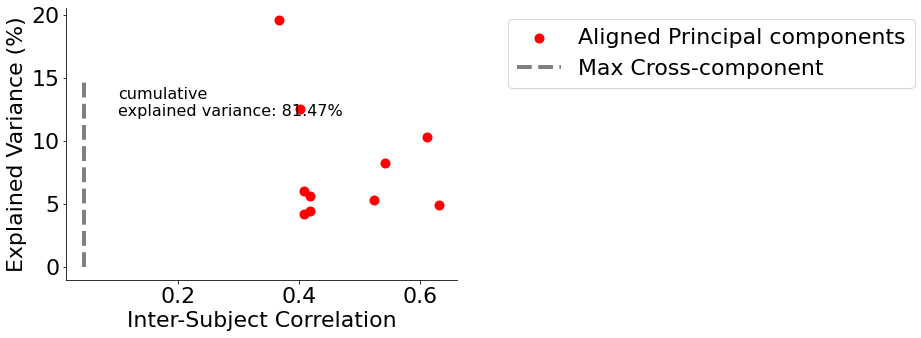

In [42]:
import matplotlib
font = {'weight' : 'normal',
        'size'   : 22}
matplotlib.rc('font', **font)
NPC_TO_ALIGN = 10
# ---------------------------------------------------------------------
# Build alignment-ready session dicts: (time × neurons × trials)
# ---------------------------------------------------------------------
data = []
for i in range(len(completeConditions)):
    bst       = completeBinned[i]
    bst       = np.transpose(bst,(1,2,0))
    print(bst.shape)
    if(len(bst)>=20):
        condition = np.array(completeConditions[i])
        timeB     = np.arange(len(bst[0]))*bin_size
        print(len(timeB),len(condition))
        session   = {'response':np.array(bst),'condition':condition,'time':timeB}
        data.append(session)
        
# ---------------------------------------------------------------------
# Align sessions into shared subspace
# ---------------------------------------------------------------------
condition_vars = []  # not used here
pars = {
    'alignment': {'nPCs_align': NPC_TO_ALIGN},
    'align_proj': {'condition_vars': []}
}

# (Re)load alignment module (optional during iterative dev)
condition_vars = []
pars           = {}
pars['alignment'] ={}
pars['alignment']["nPCs_align"]=NPC_TO_ALIGN
pars["align_proj"]={}
pars["align_proj"]["condition_vars"]=[]

import importlib
import compute_session_alignment
importlib.reload(compute_session_alignment)
D_align,D_cond_avg_proj_align,align_stats =  compute_session_alignment.compute_session_alignment(data, condition_vars, pars)

# ---------------------------------------------------------------------
# Select well-aligned PCs using on-diagonal vs off-diagonal similarity
# ---------------------------------------------------------------------
alignMatrix = np.abs(align_stats['align_sim'])
offD = [alignMatrix[i,j] for i in range(len(alignMatrix)) for j in range(i)]
onD  = [alignMatrix[i,i] for i in range(len(alignMatrix))]
fig,ax = plt.subplots(figsize=(7,5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

pcVar = np.array(list([align_stats['varExp_pc'][0]]) + list(np.diff(align_stats['varExp_pc'])))[:pars['alignment']["nPCs_align"]]
reject_components = np.where(onD<=np.max(offD))[0]
accepted_components = [i for i in range(len(onD)) if i not in reject_components]
print(reject_components,pcVar[reject_components])
print(np.sum(pcVar[accepted_components]))

#ax.spines['left'].set_visible(False)
plt.scatter(np.array(onD)[accepted_components],pcVar[accepted_components],color='red',label='Aligned Principal components',linewidth=4)
plt.vlines(np.max(offD),0,15,color='gray',zorder=0,label='Max Cross-component',linewidth=4,linestyle='--')
plt.xlabel('Inter-Subject Correlation')
plt.ylabel('Explained Variance (%)')
plt.legend(bbox_to_anchor=(2.2,1))
#plt.yticks([])
plt.text(0.1,12,'cumulative\nexplained variance: '+str(np.round(np.sum(pcVar[accepted_components]),2))+'%',fontsize=16)
#plt.tight_layout()
#plt.savefig('./corr_values_all.svg',dpi=100)
plt.show()

# ---------------------------------------------------------------------
# Optionally residualize by condition (currently NO residuals), then concat
# ---------------------------------------------------------------------
from copy import deepcopy
Z_align = deepcopy(D_align)
for i in range(len(Z_align)):
    z = Z_align[i]
    uC = np.unique(z['condition'])
    for uCi in uC:
        w = np.where(z['condition']==uCi)[0]
        D_cond_mean = np.mean(z["response"][:,:,w], axis=2, keepdims=False)
        for wi in w:
            Z_align[i]['response'][:,:,wi] = Z_align[i]['response'][:,:,wi]#-D_cond_mean  # NO RESIDUALS
            
# concatenate sessions
X            = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))],axis=2)
X = X[accepted_components]
timeX        = np.arange(len(X[0]))*bin_size #Z_align[0]['time']
time_labels  = np.ones(len(timeX),dtype=np.double)
trial_labels = np.concatenate([Z_align[i]['condition'] for i in range(len(Z_align))],dtype=np.double)
opts  = {}
rseed = 0
X.shape

# ---------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------
np.save('../Data/activity_250ms_3maint.npy',X)
np.save('../Data/probes.npy',np.concatenate(completeProbes))
np.save('../Data/probes_sep.npy',np.array(completeProbes,dtype=object))
np.save('../Data/subjs.npy',np.concatenate(completeSubj))
np.save('../Data/subjs_sep.npy',np.array(completeSubj,dtype=object))
np.save('../Data/in.npy',np.concatenate(completeIN))
np.save('../Data/letters.npy',np.concatenate(completeLetters))
np.save('../Data/letters_sep.npy',np.array(completeLetters,dtype=object))
np.save('../Data/binned.npy',np.array(completeBinned,dtype=object))
np.save('../Data/reaction.npy',np.array(completeReaction,dtype=object))
np.save('../Data/units.npy',np.array(completeUnits,dtype=object))
np.save('../Data/trial_corrInfo.npy',np.array(complete_N,dtype=object))